# 04. Object-scale localization diagnostics

기존 checkpoint를 **평가만** 하여 small/medium/large 객체별 `AP`, `AP50`, `AP75`, `AR`을 계산합니다. 학습 함수는 호출하지 않으며 기존 checkpoint, history, 종합 분석 결과를 수정하지 않습니다.

- `AP`: AP@[IoU=0.50:0.95]
- `AP50` / `AP75`: 각각 IoU 0.50 / 0.75에서의 AP
- `AR`: AR@[IoU=0.50:0.95], maxDets=100
- COCO scale 기준: small `< 32^2`, medium `32^2 ~ 96^2`, large `> 96^2` pixel area


In [1]:
from pathlib import Path
import gc, importlib, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from transformers import AutoImageProcessor

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)

ExperimentConfig = config_module.ExperimentConfig
DataBundle = data_module.DataBundle
VOCDataset = data_module.VOCDataset
collate_detection_batch = data_module.collate_detection_batch
parse_voc_record = data_module.parse_voc_record
load_checkpoint = eval_module.load_checkpoint


d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

현재 `SEEDS = [42, 43, 44]`의 checkpoint를 모두 평가합니다. 그래프의 막대와 오차선은 세 seed의 평균과 표준편차입니다. 학습 당시 설정과 동일해야 checkpoint를 올바르게 불러올 수 있습니다.


In [2]:
RUN_MODE = 'smoke'
SEEDS = [42,43,44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
FEATURE_LEVEL = 0
IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
    feature_level=FEATURE_LEVEL,
)
SEED_TAG = '-'.join(map(str, SEEDS))
RESULT_PATH = CONFIG.output_dir / f'object_scale_diagnostics_seeds{SEED_TAG}.csv'
FIGURE_PATH = CONFIG.output_dir / f'object_scale_ap_seeds{SEED_TAG}.png'
CONFIG.as_dict(), RESULT_PATH, FIGURE_PATH


({'root': 'D:\\gt-super',
  'run_mode': 'smoke',
  'checkpoint': 'SenseTime/deformable-detr',
  'train_images': 400,
  'val_images': 100,
  'epochs': 7,
  'batch_size': 2,
  'num_workers': 0,
  'image_size': {'shortest_edge': 384, 'longest_edge': 640},
  'lr': 0.0002,
  'backbone_lr': 2e-05,
  'weight_decay': 0.0001,
  'grad_clip': 0.1,
  'base_aux_weight': 0.5,
  'feature_level': 0,
  'horizontal_flip_p': 0.5,
  'use_amp': True,
  'deterministic': True,
  'save_epoch_checkpoints': False,
  'device': 'cuda',
  'experiments': ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e'],
  'seed': 42,
  'data_seed': 42},
 WindowsPath('D:/gt-super/outputs/detr_gt_auxiliary/object_scale_diagnostics_seeds42-43-44.csv'),
 WindowsPath('D:/gt-super/outputs/detr_gt_auxiliary/object_scale_ap_seeds42-43-44.png'))

## 기존 split과 checkpoint 확인

`prepare_data()`는 manifest를 다시 저장하므로 사용하지 않습니다. 기존 `voc2007_split_manifest.json`을 읽어 학습 때와 동일한 validation subset만 복원합니다.


In [3]:
MANIFEST_PATH = CONFIG.output_dir / 'voc2007_split_manifest.json'
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f'기존 split manifest가 없습니다: {MANIFEST_PATH}')
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
if manifest.get('data_seed') != DATA_SEED:
    raise ValueError(f"manifest data_seed={manifest.get('data_seed')} != 설정값 {DATA_SEED}")

checkpoint_rows = []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'size_mb': path.stat().st_size / 1024**2 if path.exists() else np.nan,
            'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
if not checkpoint_df['exists'].all():
    missing = checkpoint_df.loc[~checkpoint_df['exists'], 'path'].tolist()
    raise FileNotFoundError('Missing checkpoints:\n' + '\n'.join(missing))


,experiment,seed,exists,size_mb,path
0,baseline,42,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
1,shared_detach,42,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...
2,shared_e2e,42,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
3,separate_e2e,42,True,462.350030,D:\gt-super\cache\checkpoints\checkpoint_smoke...
4,baseline,43,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
5,shared_detach,43,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...
6,shared_e2e,43,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
7,separate_e2e,43,True,462.349969,D:\gt-super\cache\checkpoints\checkpoint_smoke...
8,baseline,44,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
9,shared_detach,44,True,461.335190,D:\gt-super\cache\checkpoints\checkpoint_smoke...


## Validation 데이터 로드

여기서는 기존 파일을 읽기만 합니다. validation loader는 shuffle 없이 구성됩니다.


In [4]:
val_ids = manifest['full_val_ids'][:VAL_IMAGES]
val_records = [parse_voc_record(CONFIG, str(image_id)) for image_id in tqdm(val_ids, desc='VOC val XML')]
try:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint)

BUNDLE = DataBundle(
    processor=processor, train_records=[], val_records=val_records,
    full_train_records=[], full_val_records=val_records,
)
collate_fn = lambda batch: collate_detection_batch(batch, BUNDLE.processor, CONFIG)
VAL_LOADER = DataLoader(
    VOCDataset(BUNDLE.val_records, CONFIG, training=False),
    batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(), collate_fn=collate_fn,
)
print({'val_images': len(BUNDLE.val_records), 'device': str(CONFIG.device)})


VOC val XML: 100%|██████████| 100/100 [00:00<00:00, 2846.05it/s]

{'val_images': 100, 'device': 'cuda'}


## 객체 크기별 상세 평가

각 checkpoint는 한 번씩 inference합니다. COCO `precision` tensor에서 각 area와 IoU 0.50/0.75를 직접 선택하고, scale별 `AR`은 TorchMetrics의 `mar_small`, `mar_medium`, `mar_large`를 사용합니다.


In [5]:
def valid_mean(values):
    values = values[values >= 0]
    return float(values.mean()) if values.numel() else np.nan

@torch.inference_mode()
def evaluate_object_scales(experiment, seed):
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval()
    metric = MeanAveragePrecision(
        box_format='xyxy', iou_type='bbox', class_metrics=True,
        extended_summary=True, iou_thresholds=IOU_THRESHOLDS,
    )
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False):
            result = model(
                pixel_values=batch['pixel_values'].to(CONFIG.device, non_blocking=True),
                pixel_mask=batch['pixel_mask'].to(CONFIG.device, non_blocking=True),
                labels=None,
            )
            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            predictions = BUNDLE.processor.post_process_object_detection(
                result['outputs'], threshold=0.0, target_sizes=sizes,
            )
            predictions = [{k: v.detach().cpu() for k, v in item.items()} for item in predictions]
            targets = [
                {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
                for target in batch['eval_targets']
            ]
            metric.update(predictions, targets)
        values = metric.compute()
        # precision: [IoU, recall, class, area, max_detections]
        # area index 1=small, 2=medium, 3=large; max_detections index -1=100
        precision = values['precision']
        rows = []
        for scale, suffix, area_index in [
            ('small', 'small', 1), ('medium', 'medium', 2), ('large', 'large', 3),
        ]:
            ap = float(values[f'map_{suffix}'])
            ar = float(values[f'mar_{suffix}'])
            rows.append({
                'experiment': experiment, 'seed': seed, 'scale': scale,
                'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
                'AP': ap if ap >= 0 else np.nan,
                'AP50': valid_mean(precision[IOU_THRESHOLDS.index(0.50), :, :, area_index, -1]),
                'AP75': valid_mean(precision[IOU_THRESHOLDS.index(0.75), :, :, area_index, -1]),
                'AR': ar if ar >= 0 else np.nan,
            })
        return rows
    finally:
        model.close()
        model.cpu()
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


In [6]:
rows = []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        rows.extend(evaluate_object_scales(experiment, seed))
scale_df = pd.DataFrame(rows)
scale_df.to_csv(RESULT_PATH, index=False)
display(scale_df.style.format({metric: '{:.4f}' for metric in ['AP', 'AP50', 'AP75', 'AR']}))
print('Saved:', RESULT_PATH)


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 20288.77it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

,experiment,seed,scale,checkpoint_epoch,fingerprint,AP,AP50,AP75,AR
0,baseline,42,small,7,c16286f63961237b,0.0544,0.1232,0.0542,0.0704
1,baseline,42,medium,7,c16286f63961237b,0.0712,0.1477,0.0646,0.2229
2,baseline,42,large,7,c16286f63961237b,0.0986,0.1596,0.1066,0.4841
3,shared_detach,42,small,7,c16286f63961237b,0.0405,0.1327,0.0042,0.0827
4,shared_detach,42,medium,7,c16286f63961237b,0.0870,0.1619,0.1021,0.1694
5,shared_detach,42,large,7,c16286f63961237b,0.1364,0.2067,0.1599,0.5076
6,shared_e2e,42,small,7,c16286f63961237b,0.0539,0.1023,0.0677,0.0877
7,shared_e2e,42,medium,7,c16286f63961237b,0.0909,0.1482,0.1030,0.2282
8,shared_e2e,42,large,7,c16286f63961237b,0.1078,0.1708,0.1083,0.4976
9,separate_e2e,42,small,7,c16286f63961237b,0.0431,0.1096,0.0500,0.0620


Saved: D:\gt-super\outputs\detr_gt_auxiliary\object_scale_diagnostics_seeds42-43-44.csv


## 기존 상세평가 cache와 교차 확인

03 노트북의 `comprehensive_metrics.csv`는 checkpoint 갱신 시간을 확인하지 않고 완성된 `(experiment, seed)` 행을 재사용합니다. 아래 셀은 현재 checkpoint 재평가값과 기존 cache의 scale별 `AP`가 다르면 오래된 cache 가능성을 경고합니다.


In [7]:
COMPREHENSIVE_CACHE = CONFIG.output_dir / 'comprehensive_metrics.csv'
if COMPREHENSIVE_CACHE.exists():
    cached = pd.read_csv(COMPREHENSIVE_CACHE)
    cached_scale = (
        cached.query("metric_type == 'area' and key in ['small', 'medium', 'large']")
        [['experiment', 'seed', 'key', 'value']]
        .rename(columns={'key': 'scale', 'value': 'cached_AP'})
    )
    cache_check = scale_df.merge(cached_scale, on=['experiment', 'seed', 'scale'], how='left')
    cache_check['current_minus_cached'] = cache_check['AP'] - cache_check['cached_AP']
    display(cache_check[['experiment', 'seed', 'scale', 'AP', 'cached_AP', 'current_minus_cached']])
    stale = cache_check['current_minus_cached'].abs().gt(1e-6).fillna(False)
    if stale.any():
        print('WARNING: 기존 comprehensive cache와 현재 checkpoint 결과가 다릅니다.')
        print('현재 checkpoint를 직접 평가한 object_scale_diagnostics 결과를 사용하세요.')
else:
    print('기존 comprehensive cache가 없어 교차 확인을 생략합니다.')


,experiment,seed,scale,AP,cached_AP,current_minus_cached
0,baseline,42,small,0.054370,0.041103,1.326636e-02
1,baseline,42,medium,0.071162,0.076929,-5.767092e-03
2,baseline,42,large,0.098615,0.133518,-3.490301e-02
3,shared_detach,42,small,0.040520,0.042266,-1.745876e-03
4,shared_detach,42,medium,0.087015,0.073226,1.378958e-02
5,shared_detach,42,large,0.136361,0.098229,3.813257e-02
6,shared_e2e,42,small,0.053913,0.061437,-7.523973e-03
7,shared_e2e,42,medium,0.090893,0.115618,-2.472502e-02
8,shared_e2e,42,large,0.107784,0.119562,-1.177745e-02
9,separate_e2e,42,small,0.043108,0.043108,6.938894e-18


현재 checkpoint를 직접 평가한 object_scale_diagnostics 결과를 사용하세요.


## Seed 평균·표준편차와 baseline 대비 변화

각 scale에서 세 seed의 평균·표준편차를 요약하고, 같은 seed의 baseline 대비 변화량을 계산합니다. `AP50`과 `AP75`의 변화 방향을 함께 보면 검출 여부와 box extent 정밀도 문제를 구분할 수 있습니다.


In [8]:
METRICS = ['AP', 'AP50', 'AP75', 'AR']
summary_df = scale_df.groupby(['scale', 'experiment'])[METRICS].agg(['mean', 'std', 'count'])
display(summary_df.style.format('{:.4f}'))

baseline = (
    scale_df.query("experiment == 'baseline'")
    [['seed', 'scale'] + METRICS]
    .rename(columns={metric: f'baseline_{metric}' for metric in METRICS})
)
comparison_df = scale_df.merge(baseline, on=['seed', 'scale'], how='left')
for metric in METRICS:
    comparison_df[f'delta_{metric}'] = comparison_df[metric] - comparison_df[f'baseline_{metric}']
delta_summary_df = comparison_df.groupby(['scale', 'experiment'])[[f'delta_{metric}' for metric in METRICS]].agg(['mean', 'std'])
display(delta_summary_df.style.format('{:+.4f}'))

TOLERANCE = 0.01
def diagnose(row):
    d50, d75, dar = row['delta_AP50'], row['delta_AP75'], row['delta_AR']
    if row['experiment'] == 'baseline':
        return 'reference'
    if abs(d50) <= TOLERANCE and d75 < -TOLERANCE:
        return '검출은 유지되지만 high-IoU box extent 정밀도 저하 가능성'
    if d50 < -TOLERANCE and d75 < -TOLERANCE:
        return 'localization 외 query representation/matching/feature interference 가능성'
    if dar < -TOLERANCE:
        return f"{row['scale']} 객체 recall 또는 query 할당 저하 가능성"
    return '단일 패턴으로 단정하기 어려움'

comparison_df['diagnosis'] = comparison_df.apply(diagnose, axis=1)
display(comparison_df[['experiment', 'seed', 'scale', 'delta_AP', 'delta_AP50', 'delta_AP75', 'delta_AR', 'diagnosis']])


,experiment,seed,scale,delta_AP,delta_AP50,delta_AP75,delta_AR,diagnosis
0,baseline,42,small,0.000000,0.000000,0.000000,0.000000,reference
1,baseline,42,medium,0.000000,0.000000,0.000000,0.000000,reference
2,baseline,42,large,0.000000,0.000000,0.000000,0.000000,reference
3,shared_detach,42,small,-0.013849,0.009584,-0.049986,0.012346,검출은 유지되지만 high-IoU box extent 정밀도 저하 가능성
4,shared_detach,42,medium,0.015854,0.014179,0.037536,-0.053562,medium 객체 recall 또는 query 할당 저하 가능성
5,shared_detach,42,large,0.037746,0.047111,0.053270,0.023540,단일 패턴으로 단정하기 어려움
6,shared_e2e,42,small,-0.000456,-0.020832,0.013507,0.017284,단일 패턴으로 단정하기 어려움
7,shared_e2e,42,medium,0.019731,0.000460,0.038422,0.005250,단일 패턴으로 단정하기 어려움
8,shared_e2e,42,large,0.009169,0.011170,0.001618,0.013568,단일 패턴으로 단정하기 어려움
9,separate_e2e,42,small,-0.011262,-0.013506,-0.004158,-0.008333,단일 패턴으로 단정하기 어려움


Saved: D:\gt-super\outputs\detr_gt_auxiliary\object_scale_ap_seeds42-43-44.png


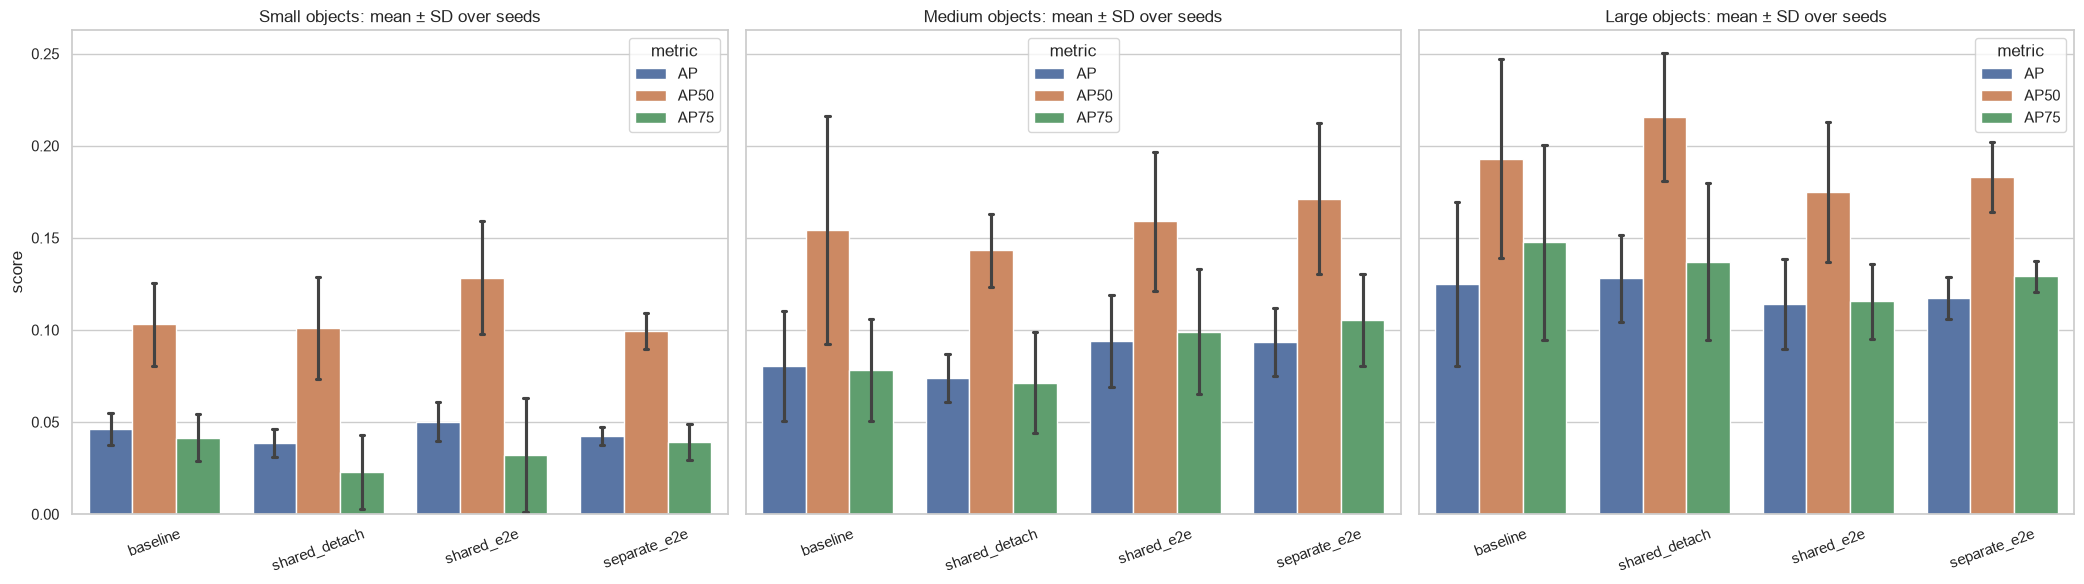

In [9]:
plot_df = scale_df.melt(
    id_vars=['experiment', 'seed', 'scale'], value_vars=['AP', 'AP50', 'AP75'],
    var_name='metric', value_name='value',
)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for axis, scale in zip(axes, ['small', 'medium', 'large']):
    sns.barplot(
        data=plot_df.query('scale == @scale'), x='experiment', y='value', hue='metric',
        estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.set_title(f'{scale.capitalize()} objects: mean ± SD over seeds')
    axis.set_xlabel('')
    axis.set_ylabel('score' if axis is axes[0] else '')
    axis.tick_params(axis='x', rotation=20)
    axis.legend(title='metric')
plt.tight_layout()
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
print('Saved:', FIGURE_PATH)
plt.show()
